## 교통약자 거주지-인프라 연계성 분석
"시설부하지수 상위 20% 집중관리구역 후보는 실제로 고령자, 장애인 밀집 지역과 연결되는가?"

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import koreanize_matplotlib

from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
import re

In [7]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

In [20]:
top_20_df = pd.read_csv("../../data/processed/team/top_20_df.csv")
base_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")

elder_raw = pd.read_excel("../../data/raw/고령자현황_20260408143455.xlsx", sheet_name='데이터', header=None)
disabled_raw = pd.read_excel("../../data/raw/장애인+현황(장애유형별_동별)_20260408143505.xlsx", sheet_name='데이터', header=None)
district_station_raw = pd.read_csv("../../data/raw/서울교통공사_자치구별 지하철역 정보_20250804.CSV", encoding="cp949")

In [21]:
candidate_df = top_20_df.copy()
all_station_df = base_df.copy()

In [22]:
# 고령자 현황 정리
elder_df = elder_raw.iloc[5:, [1, 2, 5]].copy()
elder_df.columns = ['자치구', '전체인구', '고령자수']
elder_df = elder_df[elder_df['자치구'].notna()].copy()

elder_df['전체인구'] = pd.to_numeric(elder_df['전체인구'], errors='coerce')
elder_df['고령자수'] = pd.to_numeric(elder_df['고령자수'], errors='coerce')
elder_df['고령자비율'] = elder_df['고령자수'] / elder_df['전체인구']

In [24]:
# 장애인 현황 정리
disabled_df = disabled_raw.iloc[5:, [1, 2]].copy()
disabled_df.columns = ['자치구', '장애인수']
disabled_df = disabled_df[disabled_df['자치구'].notna()].copy()

disabled_df['장애인수'] = pd.to_numeric(disabled_df['장애인수'], errors='coerce')

In [26]:
# 자치구 통합 지표 생성
district_metrics = elder_df.merge(disabled_df, on='자치구', how='inner')
district_metrics['장애인비율'] = district_metrics['장애인수'] / district_metrics['전체인구']

In [27]:
# 표준점수 기반 종합 밀집 점수
district_metrics['고령자_z'] = (
    district_metrics['고령자수'] - district_metrics['고령자수'].mean()
) / district_metrics['고령자수'].std(ddof=0)

district_metrics['장애인_z'] = (
    district_metrics['장애인수'] - district_metrics['장애인수'].mean()
) / district_metrics['장애인수'].std(ddof=0)

district_metrics['밀집종합점수'] = district_metrics['고령자_z'] + district_metrics['장애인_z']

In [29]:
# 상위 25% 밀집 자치구 플래그
district_metrics['고령자밀집_상위25'] = district_metrics['고령자수'] >= district_metrics['고령자수'].quantile(0.75)
district_metrics['장애인밀집_상위25'] = district_metrics['장애인수'] >= district_metrics['장애인수'].quantile(0.75)
district_metrics['종합밀집_상위25'] = district_metrics['밀집종합점수'] >= district_metrics['밀집종합점수'].quantile(0.75)

district_metrics.sort_values('밀집종합점수', ascending=False).head(10)

,자치구,전체인구,고령자수,고령자비율,장애인수,장애인비율,고령자_z,장애인_z,밀집종합점수,고령자밀집_상위25,장애인밀집_상위25,종합밀집_상위25
15,강서구,556370,113320,0.203677,27946,0.050229,1.565859,2.253112,3.818971,True,True,True
10,노원구,489003,104776,0.214265,25807,0.052775,1.202405,1.867355,3.069760,True,True,True
23,송파구,649759,119251,0.183531,20173,0.031047,1.818157,0.851292,2.669450,True,True,True
11,은평구,459586,102485,0.222994,21324,0.046398,1.104949,1.058869,2.163818,True,True,True
24,강동구,503997,98148,0.194739,18967,0.037633,0.920457,0.633797,1.554254,True,False,True
20,관악구,497391,92939,0.186853,19959,0.040127,0.698871,0.812699,1.511570,True,True,True
6,중랑구,383764,88128,0.229641,20066,0.052287,0.494216,0.831995,1.326212,False,True,True
16,구로구,408238,88122,0.215859,19228,0.047100,0.493961,0.680866,1.174828,False,True,False
22,강남구,562508,95530,0.169829,15434,0.027438,0.809090,-0.003362,0.805728,True,False,False
7,성북구,437496,87537,0.200086,16901,0.038631,0.469076,0.261204,0.730280,False,False,False


In [31]:
# 자치구별 지하철역 정보 파싱
rows = []
for _, r in district_station_raw.iterrows():
    gu = r['자치구']
    text = str(r['해당역(호선)'])
    items = [x.strip() for x in text.split(', ')]

    for item in items:
        m = re.match(r'(.+?)\((.+?)\)$', item)
        if m:
            station = m.group(1).strip()
            line = m.group(2).strip()
        else:
            station = item.strip()
            line = None

        rows.append([gu, station, line])

station_gu = pd.DataFrame(rows, columns=['자치구', '역명', '호선'])

In [32]:
# 역명 보정
station_gu['역명_norm'] = station_gu['역명'].replace({
    '서울': '서울',
    '구로디지털': '구로디지털단지'
})

In [33]:
# 역별 자치구 연결 함수
def map_station_to_gu(station_name, line_str):
    station_name = str(station_name)
    line_list = [x.strip() for x in str(line_str).split(',')]

    # 1차: 역명+호선 일치
    matched = station_gu[
        (station_gu['역명_norm'] == station_name) &
        (station_gu['호선'].astype(str).isin(line_list))
    ]['자치구'].dropna().unique().tolist()

    # 2차: 역명만 일치
    if len(matched) == 0:
        matched = station_gu[
            station_gu['역명_norm'] == station_name
        ]['자치구'].dropna().unique().tolist()

    return matched

In [34]:
# 후보역(top_20_df)에 자치구 연결
candidate_map = candidate_df[['지하철역', '호선명', '시설부하지수', '무임승하차', '가중편의시설합', 'TOTAL']].copy()
candidate_map['자치구_list'] = candidate_map.apply(
    lambda x: map_station_to_gu(x['지하철역'], x['호선명']),
    axis=1
)

candidate_exploded = candidate_map.explode('자치구_list').rename(columns={'자치구_list': '자치구'})
candidate_merged = candidate_exploded.merge(district_metrics, on='자치구', how='left')

In [35]:
# station-level로 다시 집계
q1_station = candidate_merged.groupby(
    ['지하철역', '호선명', '시설부하지수', '무임승하차', '가중편의시설합', 'TOTAL'],
    as_index=False
).agg(
    연결자치구수=('자치구', 'nunique'),
    자치구=('자치구', lambda x: ', '.join(sorted(set(x.dropna())))),
    평균_고령자수=('고령자수', 'mean'),
    평균_고령자비율=('고령자비율', 'mean'),
    평균_장애인수=('장애인수', 'mean'),
    평균_장애인비율=('장애인비율', 'mean'),
    평균_밀집종합점수=('밀집종합점수', 'mean'),
    고령자밀집구_연결=('고령자밀집_상위25', 'max'),
    장애인밀집구_연결=('장애인밀집_상위25', 'max'),
    종합밀집구_연결=('종합밀집_상위25', 'max')
)

In [36]:
# 서울 외 지역 제외
q1_station_seoul = q1_station[q1_station['평균_고령자수'].notna()].copy()

print("질문 1 분석 대상 역 수(서울 내):", len(q1_station_seoul))
q1_station_seoul.head()

질문 1 분석 대상 역 수(서울 내): 49


,지하철역,호선명,시설부하지수,무임승하차,가중편의시설합,TOTAL,연결자치구수,자치구,평균_고령자수,평균_고령자비율,평균_장애인수,평균_장애인비율,평균_밀집종합점수,고령자밀집구_연결,장애인밀집구_연결,종합밀집구_연결
0,강남,2,18886.94,302191,16,4,1,강남구,95530.0,0.169829,15434.0,0.027438,0.805728,True,False,False
1,강변,2,23487.00,234870,10,4,1,광진구,62783.0,0.179834,12023.0,0.034438,-1.202452,False,False,False
2,광화문,5,16598.92,199187,12,6,1,종로구,30958.0,0.208033,5622.0,0.037779,-3.710643,False,False,False
3,교대,"2,3",17877.08,464804,26,11,1,서초구,72308.0,0.172451,10165.0,0.024243,-1.132349,False,False,False
4,구로디지털단지,2,20238.45,404769,20,8,1,구로구,88122.0,0.215859,19228.0,0.047100,1.174828,False,True,False


In [37]:
# 상관계수 분석
q1_corr_results = []

for col, label in [
    ('평균_고령자수', '고령자수'),
    ('평균_고령자비율', '고령자비율'),
    ('평균_장애인수', '장애인수'),
    ('평균_장애인비율', '장애인비율'),
    ('평균_밀집종합점수', '밀집종합점수')
]:
    temp = q1_station_seoul[['시설부하지수', col]].dropna()
    corr, p = pearsonr(temp['시설부하지수'], temp[col])

    q1_corr_results.append({
        '지표': label,
        '상관계수': round(corr, 3),
        'p-value': round(p, 4)
    })

q1_corr_df = pd.DataFrame(q1_corr_results)
q1_corr_df

,지표,상관계수,p-value
0,고령자수,-0.029,0.8454
1,고령자비율,0.146,0.3177
2,장애인수,0.030,0.8398
3,장애인비율,0.193,0.1840
4,밀집종합점수,0.001,0.9970


In [38]:
# 후보군 vs 전체역 비교
all_map = all_station_df[['지하철역', '호선명', '시설부하지수']].copy()
all_map['자치구_list'] = all_map.apply(
    lambda x: map_station_to_gu(x['지하철역'], x['호선명']),
    axis=1
)

all_exploded = all_map.explode('자치구_list').rename(columns={'자치구_list': '자치구'})
all_merged = all_exploded.merge(district_metrics, on='자치구', how='left')

all_station_q1 = all_merged.groupby(
    ['지하철역', '호선명', '시설부하지수'],
    as_index=False
).agg(
    평균_고령자수=('고령자수', 'mean'),
    고령자밀집구_연결=('고령자밀집_상위25', 'max'),
    장애인밀집구_연결=('장애인밀집_상위25', 'max'),
    종합밀집구_연결=('종합밀집_상위25', 'max')
)

all_station_q1 = all_station_q1[all_station_q1['평균_고령자수'].notna()].copy()

q1_link_compare = pd.DataFrame({
    '구분': ['후보역', '전체역'],
    '고령자밀집구_연결비율': [
        q1_station_seoul['고령자밀집구_연결'].mean(),
        all_station_q1['고령자밀집구_연결'].mean()
    ],
    '장애인밀집구_연결비율': [
        q1_station_seoul['장애인밀집구_연결'].mean(),
        all_station_q1['장애인밀집구_연결'].mean()
    ],
    '종합밀집구_연결비율': [
        q1_station_seoul['종합밀집구_연결'].mean(),
        all_station_q1['종합밀집구_연결'].mean()
    ]
}).round(3)

q1_link_compare

,구분,고령자밀집구_연결비율,장애인밀집구_연결비율,종합밀집구_연결비율
0,후보역,0.347,0.306,0.306
1,전체역,0.363,0.296,0.318


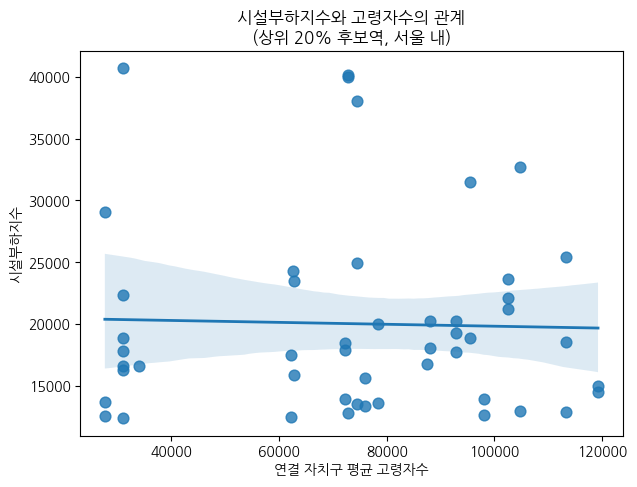

In [39]:
# 시설부하지수 vs 고령자수
plt.figure(figsize=(7, 5))
sns.regplot(
    data=q1_station_seoul,
    x='평균_고령자수',
    y='시설부하지수',
    scatter_kws={'s': 60},
    line_kws={'linewidth': 2}
)
plt.title('시설부하지수와 고령자수의 관계\n(상위 20% 후보역, 서울 내)')
plt.xlabel('연결 자치구 평균 고령자수')
plt.ylabel('시설부하지수')
plt.show()

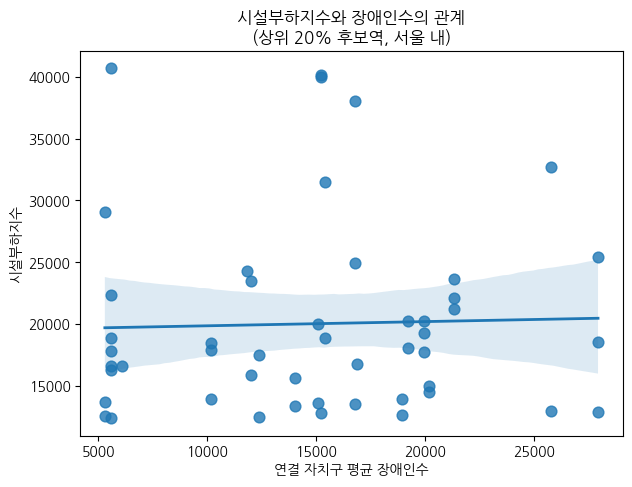

In [40]:
# 시설부하지수 vs 장애인수
plt.figure(figsize=(7, 5))
sns.regplot(
    data=q1_station_seoul,
    x='평균_장애인수',
    y='시설부하지수',
    scatter_kws={'s': 60},
    line_kws={'linewidth': 2}
)
plt.title('시설부하지수와 장애인수의 관계\n(상위 20% 후보역, 서울 내)')
plt.xlabel('연결 자치구 평균 장애인수')
plt.ylabel('시설부하지수')
plt.show()

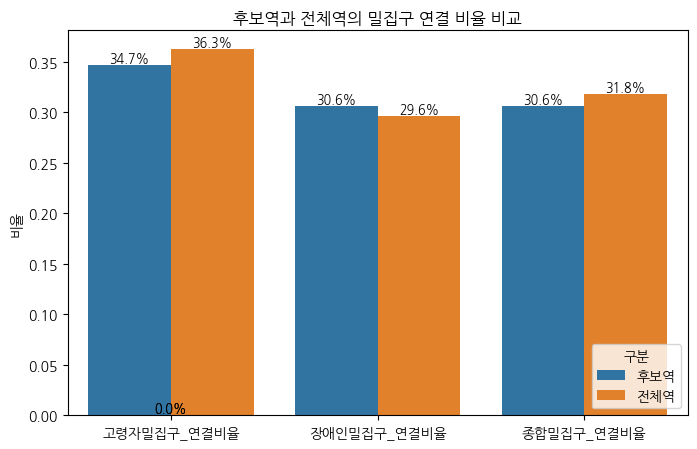

In [41]:
# 후보역 vs 전체역 밀집구 연결 비율 비교
q1_plot_df = q1_link_compare.melt(
    id_vars='구분',
    value_vars=['고령자밀집구_연결비율', '장애인밀집구_연결비율', '종합밀집구_연결비율'],
    var_name='지표',
    value_name='비율'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=q1_plot_df, x='지표', y='비율', hue='구분', errorbar=None)
plt.title('후보역과 전체역의 밀집구 연결 비율 비교')
plt.xlabel('')
plt.ylabel('비율')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1%}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=9)

plt.show()